# __Foci Detection Project__

This notebook goes through all the necessary steps to detect DNA damage in cell nuclei, called Foci.

1. __Dataset Exploration:__ Examining the dataset, visualizing images, and analyzing their properties
2. __Data Preprocessing:__ Setting up preprocessing pipelines
3. __Process Images:__ Setting up a region growing workflow to detect cell nuclei in images.



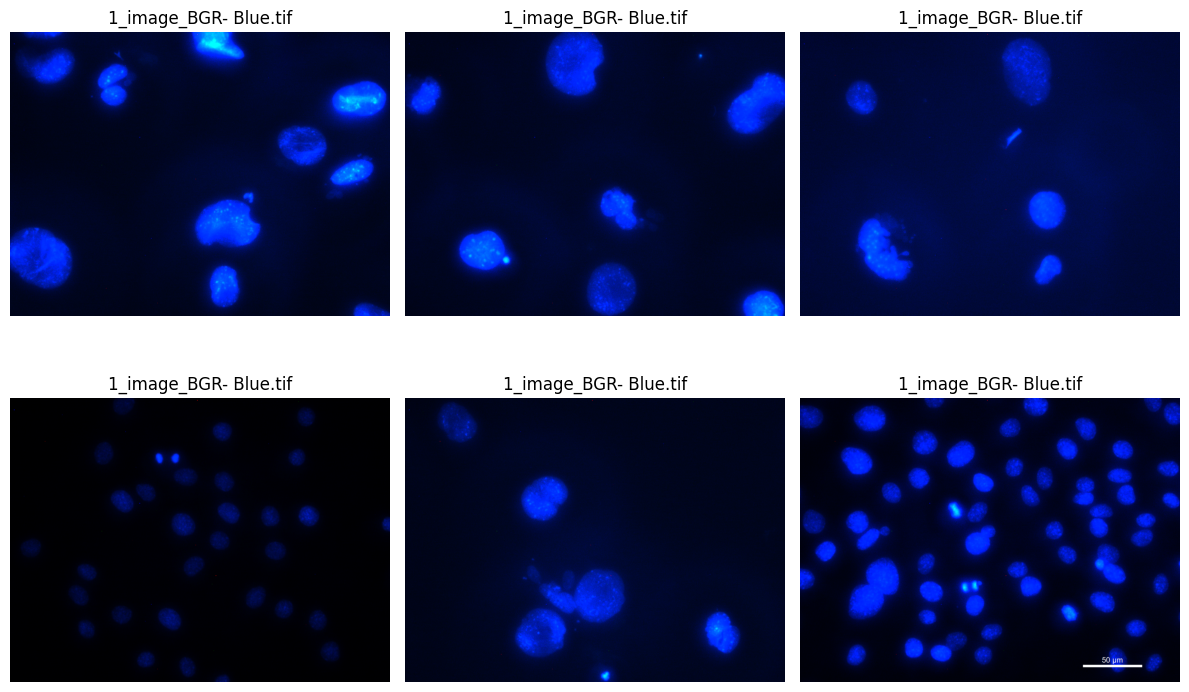

In [5]:
#import
import matplotlib.pyplot as plt
import random
from pathlib import Path
from PIL import Image

root = "data"

imgs = list(Path(root).rglob("*Blue.tif"))  # full paths
sampled = random.sample(imgs, 6)

plt.figure(figsize=(12, 8))
for i, img_path in enumerate(sampled, 1):
    img = Image.open(str(img_path))     # open directly
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)

plt.tight_layout()
plt.show()


As we can see, the nuclei vary in count, size and intensitiy. This creates some challanges:
- Wide variation in nucleus size (tiny to very large) makes fixed-scale detection unreliable.
- Large differences in intensity and contrast hinder thresholding and consistent segmentation.
- Variable cell density causes problems in both sparse and highly crowded regions.
- Overlapping or touching nuclei make instance separation difficult.
- Shape variability (round, elongated, irregular, fragmented) breaks shape-based assumptions.
- Noise, artifacts, and uneven illumination can mimic nuclei or obscure true ones.
- Staining variability across experiments or labs reduces model generalization.
- Domain shifts between microscopes, magnifications, or imaging protocols.
- Low contrast nuclei blend into the background.
- Ambiguous boundaries due to blur or imaging limitations.
- Limited or inconsistent annotations, especially in dense clusters.
- Scale changes between datasets (different pixel sizes or resolutions).

Overall intensity range: 0 - 255
Number of images: 33
Total pixels: 143320320


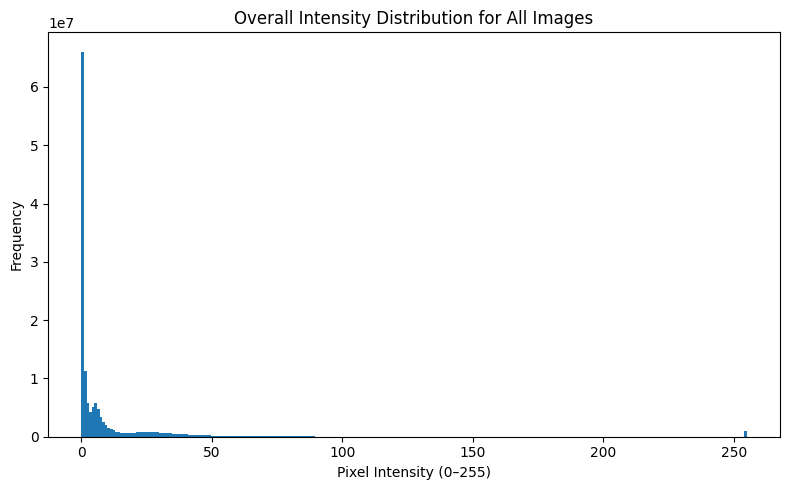

In [7]:
# ---Quick EDA---
# Image Intensity

import numpy as np

def plot_overall_intensity_histogram(root="data"):

    all_pixels = []

    # Load intensities from every image
    for img_path in imgs:
        img = Image.open(str(img_path)).convert("L")   # grayscale
        arr = np.array(img).ravel()
        all_pixels.append(arr)

    # Flatten into one big 1D array
    all_pixels = np.concatenate(all_pixels)

    print("Overall intensity range:", all_pixels.min(), "-", all_pixels.max())
    print("Number of images:", len(imgs))
    print("Total pixels:", len(all_pixels))

    # Combined histogram
    plt.figure(figsize=(8, 5))
    plt.hist(all_pixels, bins=256)
    plt.title("Overall Intensity Distribution for All Images")
    plt.xlabel("Pixel Intensity (0–255)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

plot_overall_intensity_histogram("data")



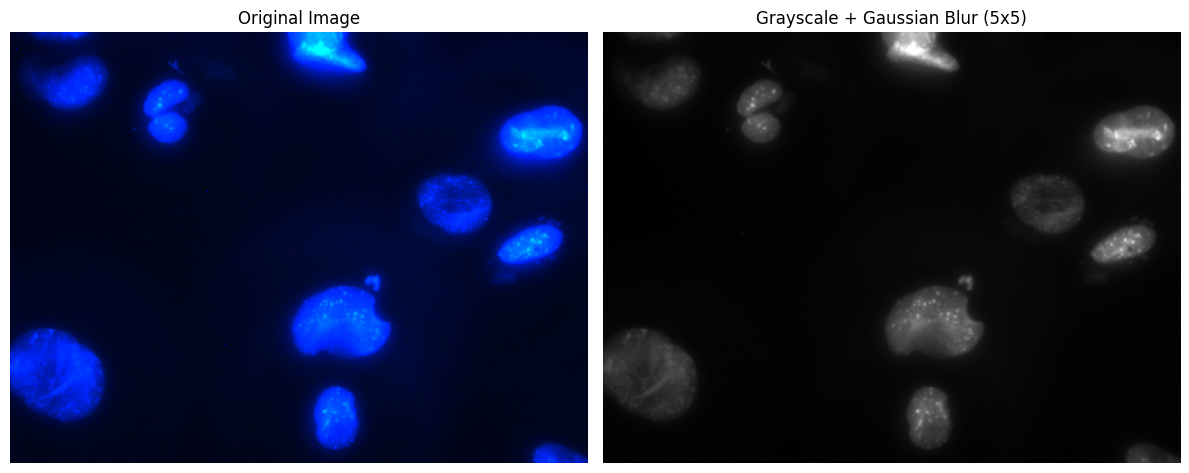

In [15]:
# Data Preprocessing
#- Grayscale
#- Gaussian blurr

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io, filters, measure, color

original_image = io.imread(str(sampled[0]))

# Grayscale Conversion
if original_image.ndim == 3:
    # This result is a 2D float array (0.0 to 1.0)
    grayscale_image = color.rgb2gray(original_image)
else:
    # If the image is already 2D (grayscale), use it directly
    grayscale_image = original_image

# Gaussian Blur
blurred_image = cv2.GaussianBlur(grayscale_image, (5, 5), 0)


# Create figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#Original Image
# Use cmap=None for color images, 'gray' for 2D images
axes[0].imshow(original_image, cmap=None if original_image.ndim == 3 else 'gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

#Blurred Grayscale Image
axes[1].imshow(blurred_image, cmap='gray')
axes[1].set_title('Grayscale + Gaussian Blur (5x5)')
axes[1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:


# Assuming the functions from Step 1 (create_li_mask and extract_features)
# and the variable blurred_image from the previous cell are available.

# 1. Segment using the Li Threshold and create initial labels
# This is equivalent to your old 'threshold_image' + 'region_growing' steps
initial_labels, binary_mask = create_li_mask(blurred_image)

# 2. Filter small regions and extract properties (features)
# We use a dummy name 'temp_image' since we're just testing one image
cell_data, final_labels = extract_features(
    labels=initial_labels,
    intensity_image=blurred_image,
    image_name="temp_image"
)

# 3. Create the final bitmask (binary image of the filtered cells)
# The bitmask is the filtered label map converted to a binary image (0 or 1)
final_bitmask = (final_labels > 0).astype(np.uint8)

# 4. Display the results
print(f"Region Growing completed. Found {len(cell_data)} cells after filtering.")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Region Growing Results", fontsize=14)

# A. Blurred Input Image
axes[0].imshow(blurred_image, cmap='gray')
axes[0].set_title('Blurred Input Image')
axes[0].axis('off')

# B. Final Filtered Bitmask
# Note: Use cmap='gray' for the binary image
axes[1].imshow(final_bitmask, cmap='gray')
axes[1].set_title('Final Filtered Bitmask (Region Growing)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 5. Display the DataFrame for the current image
if cell_data:
    df_single_image = pd.DataFrame(cell_data)
    print("\nCell Features Extracted:")
    print(df_single_image.head())

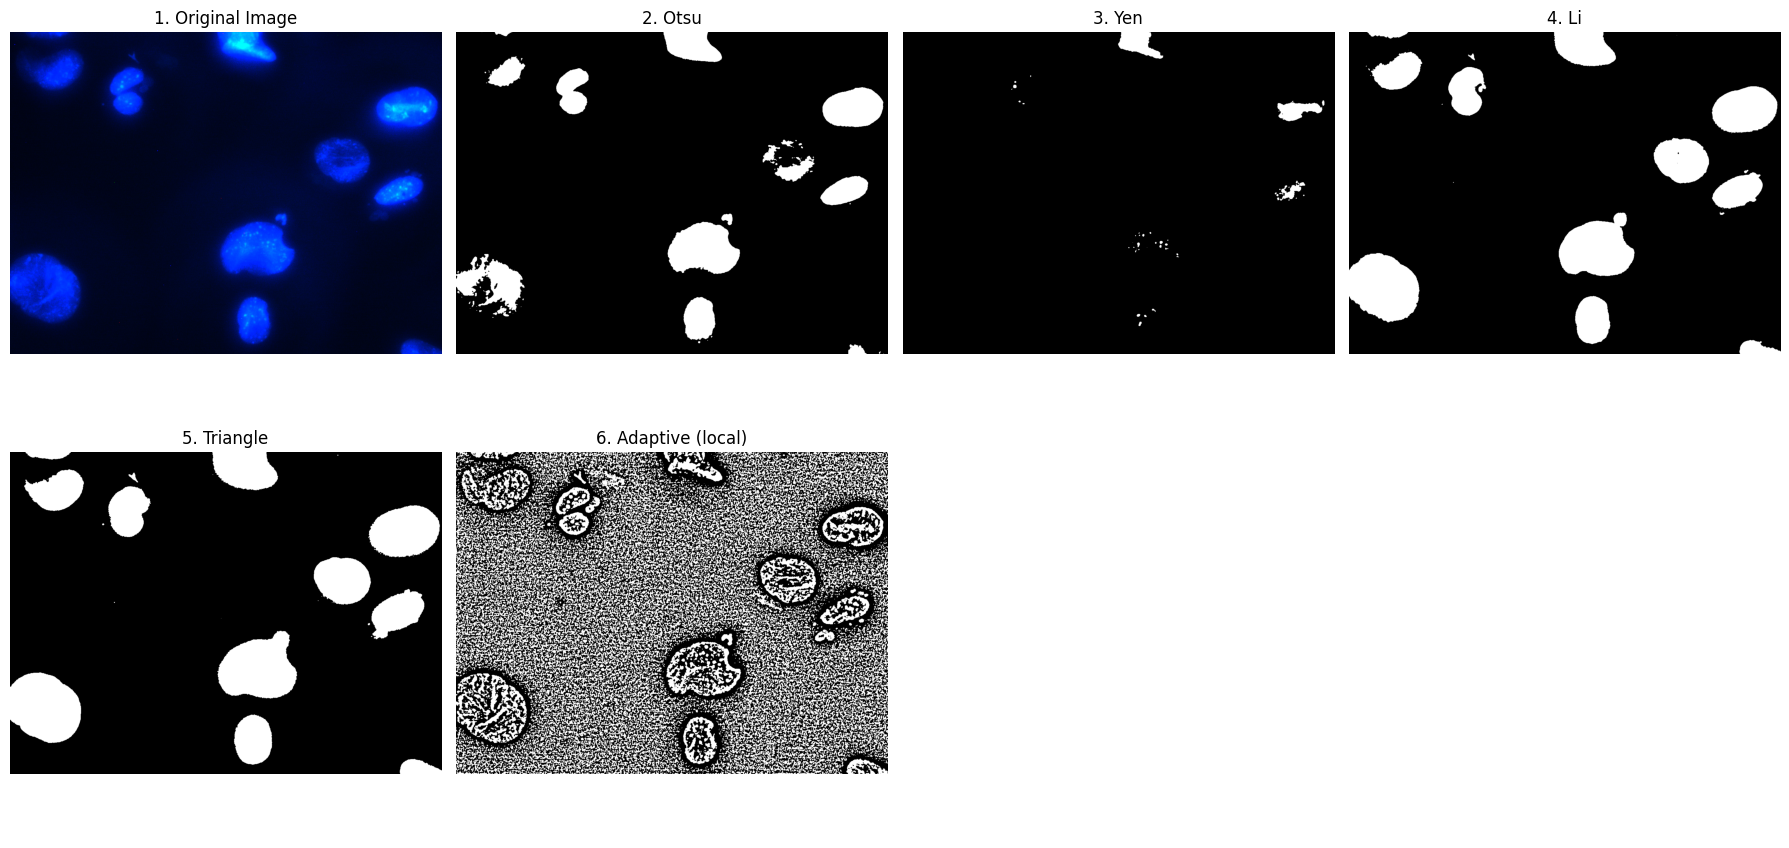


Region-Flächen (in Pixel):
Otsu: 130778.0
Yen: 16110.0
Li: 194777.0
Triangle: 226407.0
Adaptive (local): 649621.0


In [21]:
import cv2
import numpy as np
from skimage import io, filters, measure, morphology, color
import matplotlib.pyplot as plt
from skimage.filters import threshold_local

def compare_threshold_methods(original_image, blurred_image):
    # 'image' variable now correctly references the input for thresholding (the blurred image)
    image = blurred_image

    methods = {
        "Otsu": filters.threshold_otsu,
        "Yen": filters.threshold_yen,
        "Li": filters.threshold_li,
        "Triangle": filters.threshold_triangle,
        "Adaptive (local)": lambda img: threshold_local(img, block_size=35)
    }

    # Prepare list of images/titles for plotting (includes original and blurred)
    plot_images = [(original_image, "Original Image", original_image.ndim == 2)]

    # 2 rows, 3 columns is usually enough for 6 thresholds + 1 original, but 2x4 is cleaner
    fig, axs = plt.subplots(2, 4, figsize=(18, 9))
    axs = axs.ravel() # Flatten the axes array for easy indexing

    # --- Plot 1: Original Image ---
    # Determine the correct colormap for the original image
    cmap_original = 'gray' if original_image.ndim == 2 else None
    axs[0].imshow(original_image, cmap=cmap_original)
    axs[0].set_title("1. Original Image")
    axs[0].axis("off")

    binary_images = {}

    # --- Plot 2-7: Threshold Methods ---
    for i, (name, method) in enumerate(methods.items()):

        # Calculate threshold
        if name == "Adaptive (local)":
            thresholded = image > method(image)
        else:
            threshold_value = method(image)
            thresholded = image > threshold_value

        binary_images[name] = thresholded

        # Plot on the subsequent axes (index starts at 1)
        axs[i+1].imshow(thresholded, cmap="gray")
        axs[i+1].set_title(f"{i+2}. {name}")
        axs[i+1].axis("off")

    # Hide unused axes (e.g., axs[7] if you use 2x4 for 6 methods + 1 original)
    for i in range(len(methods) + 1, len(axs)):
        axs[i].axis("off")

    plt.tight_layout()
    plt.show()

    # Analyse der Flächen (Analysis of Areas - unchanged)
    print("\nRegion-Flächen (in Pixel):")
    for name, binary in binary_images.items():
        labeled = measure.label(binary)
        props = measure.regionprops(labeled)
        total_area = sum([r.area for r in props])
        print(f"{name}: {total_area}")

compare_threshold_methods(original_image, blurred_image)